<!-- Cell 0 -->
# 2D Gaussian Splatting on CPU

This notebook reconstructs a small target image as a sum of anisotropic 2D Gaussian splats. Each splat has a position, rotated scale, color, and opacity. Gradient descent optimizes these parameters to reproduce the target.

**Demo configuration**

- Target: `skimage.data.chelsea()`, resized to `128 × 128`
- Approximately 400 randomly initialized splats
- Anisotropic, rotated Gaussians
- L1 pixel loss with Adam
- Pure PyTorch on CPU; no CUDA required

In [1]:
# cell 1

%pip install torch numpy matplotlib scikit-image
%pip install torch --index-url https://download.pytorch.org/whl/cpu

import math
import time

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from skimage import data as skdata, transform as sktransform
from skimage.metrics import structural_similarity as ssim

%matplotlib inline
torch.set_default_dtype(torch.float32)

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


<!-- Cell 2 -->

## 1. Load and preprocess the target image

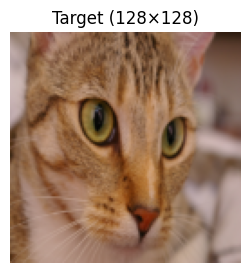

In [2]:
# Cell 3

H, W = 128, 128

target_np = sktransform.resize(skdata.chelsea(), (H, W), anti_aliasing=True).astype(np.float32)
target_t = torch.from_numpy(target_np)

plt.figure(figsize=(3, 3))
plt.imshow(target_np)
plt.title(f"Target ({H}×{W})")
plt.axis("off")
plt.show()

<!-- Cell 4 -->

## 2. Gaussian representation and renderer

Each Gaussian $i$ has:
- a center $\mu_i = (x_i, y_i)$ in pixel coordinates
- an oriented scale: axis lengths $(s_{x,i}, s_{y,i})$ and rotation angle $\theta_i$,
  which together define a covariance matrix $\Sigma_i = R(\theta_i)\,\mathrm{diag}(s_{x,i}^2, s_{y,i}^2)\,R(\theta_i)^\top$
- an opacity $o_i \in (0,1)$ (via sigmoid)
- a color $c_i \in (0,1)^3$ (via sigmoid)

For every pixel $p$, each Gaussian contributes a weight
$w_i(p) = \exp\left(-\tfrac{1}{2}(p-\mu_i)^\top \Sigma_i^{-1} (p-\mu_i)\right)$,
and an alpha $\alpha_i(p) = o_i \cdot w_i(p)$.

Gaussians are combined with **front-to-back alpha compositing** (the same "over"
operator used in volume rendering / 3D Gaussian Splatting), computed efficiently with
a cumulative product (no explicit Python loop over Gaussians is needed):

$$\text{image}(p) = \sum_i T_i(p)\,\alpha_i(p)\,c_i + T_{N}(p)\cdot\text{background}, \qquad T_i(p) = \prod_{j<i}\left(1-\alpha_j(p)\right)$$

**On draw order / depth:** real Gaussian Splatting gets its compositing order "for free"
from actual camera-relative depth. In a flat 2D image there's no such depth, so here we
chose a fix monotonic order for compositing. Alternatively, we can also fix a random order.

Later, we will show results with randomzied order post-training.

**Adaptive Density Control** periodically grows or shrinks the set of Gaussians during training: high-gradient Gaussians are cloned (if small) or split into two (if large) to add capacity where the image is under-reconstructed, while low-opacity Gaussians are pruned away. This happens every few iterations based on accumulated positional gradients, after which the optimizer is rebuilt to match the new parameter count.

In [ ]:
# Cell 5

class GaussianSplat2D(nn.Module):
    """Image represented as front-to-back composited 2D Gaussian splats."""

    def __init__(self, n_gaussians, height, width, seed=0):
        super().__init__()
        self.N, self.H, self.W = n_gaussians, height, width
        g = torch.Generator().manual_seed(seed)

        # Learnable centers in pixel coordinates (x, y).
        self.mu = nn.Parameter(
            torch.rand(n_gaussians, 2, generator=g)
            * torch.tensor([width, height])
        )

        # Positive axis scales are stored in log-space.
        self.log_scale = nn.Parameter(
            (torch.rand(n_gaussians, 2, generator=g) * 8 + 4).log()
        )

        # Learnable ellipse orientations in radians.
        self.theta = nn.Parameter(
            2 * math.pi * torch.rand(n_gaussians, generator=g)
        )

        # Opacity and color are constrained with sigmoid during rendering.
        self.opacity_logit = nn.Parameter(
            torch.logit(torch.ones(n_gaussians) * 0.35)
        )
        self.color_logit = nn.Parameter(
            torch.logit(torch.rand(n_gaussians, 3, generator=g))
        )

        # Learnable background color.
        self.background = nn.Parameter(torch.ones(3) * 0.5)

        # Fixed pixel-center coordinate grid.
        y, x = torch.meshgrid(
            torch.arange(height) + 0.5,
            torch.arange(width) + 0.5,
            indexing="ij",
        )
        self.register_buffer("grid_x", x)
        self.register_buffer("grid_y", y)

        # --- Densification bookkeeping ---
        # Accumulates |grad| of each Gaussian's center between densification
        # rounds, plus a hit counter so we can average it. Not parameters:
        # they're just running statistics, reset after each densify call.
        self.register_buffer("xyz_grad_accum", torch.zeros(n_gaussians))
        self.register_buffer("denom", torch.zeros(n_gaussians))

    def render(self, random_gaussian_order=False):
        # Decode scales and compute inverse-covariance entries.
        scales = self.log_scale.clamp(-2, 5).exp()
        cos_t, sin_t = self.theta.cos(), self.theta.sin()
        inv_sx2, inv_sy2 = scales.square().reciprocal().unbind(1)

        a = cos_t.square() * inv_sx2 + sin_t.square() * inv_sy2
        c = sin_t.square() * inv_sx2 + cos_t.square() * inv_sy2
        b = cos_t * sin_t * (inv_sx2 - inv_sy2)

        # Pixel offsets from each Gaussian center.
        dx = self.grid_x - self.mu[:, 0, None, None]
        dy = self.grid_y - self.mu[:, 1, None, None]

        # Mahalanobis distance and Gaussian weights.
        maha = (
            a[:, None, None] * dx.square()
            + 2 * b[:, None, None] * dx * dy
            + c[:, None, None] * dy.square()
        )
        weights = (-0.5 * maha).exp()

        # Per-pixel alpha.
        alpha = torch.sigmoid(self.opacity_logit)[:, None, None] * weights

        # Use index order by default, or a fresh random order if requested.
        order = (
            torch.randperm(self.N)
            if (random_gaussian_order and self.training)
            else torch.arange(self.N)
        )
        alpha = alpha[order]
        colors = torch.sigmoid(self.color_logit)[order]

        # Front-to-back alpha compositing.
        trans = torch.cumprod(1 - alpha, dim=0)
        trans_before = torch.cat((torch.ones_like(trans[:1]), trans[:-1]))
        contribution = trans_before * alpha

        image = torch.einsum("nhw,nc->hwc", contribution, colors)
        return image + trans[-1, ..., None] * self.background.clamp(0, 1)

    # ------------------------------------------------------------------
    # Densification
    # ------------------------------------------------------------------

    def accumulate_grad_stats(self):
        """Call once per iteration, right after loss.backward()."""
        if self.mu.grad is not None:
            self.xyz_grad_accum += self.mu.grad.norm(dim=-1)
            self.denom += 1

    @torch.no_grad()
    def densify_and_prune(
        self,
        grad_threshold=0.00002,
        opacity_threshold=0.3,
        scale_threshold=10.0,
        scale_factor=1.6,
    ):
        """Clone small/under-reconstructed Gaussians, split large/blurry
        ones, and prune near-transparent ones. Rebuilds all parameters
        and the grad-accum buffers to match the new Gaussian count.
        """
        avg_grad = self.xyz_grad_accum / self.denom.clamp(min=1)
        max_scale = self.log_scale.exp().max(dim=1).values

        needs_densify = avg_grad >= grad_threshold
        is_small = max_scale <= scale_threshold
        is_large = ~is_small

        clone_mask = needs_densify & is_small
        split_mask = needs_densify & is_large
        remove_mask = (torch.sigmoid(self.opacity_logit) < opacity_threshold)

        # --- Clone: duplicate small, high-gradient Gaussians with a
        # small positional jitter so they don't sit exactly on top of
        # their parent. ---
        new_mu, new_log_scale, new_theta = [], [], []
        new_opacity_logit, new_color_logit = [], []

        if clone_mask.any():
            jitter = torch.randn(clone_mask.sum(), 2) * 0.5
            new_mu.append(self.mu[clone_mask] + jitter)
            new_log_scale.append(self.log_scale[clone_mask])
            new_theta.append(self.theta[clone_mask])
            new_opacity_logit.append(self.opacity_logit[clone_mask])
            new_color_logit.append(self.color_logit[clone_mask])

        # --- Split: replace each large, high-gradient Gaussian with two
        # smaller ones, sampled along its own ellipse from its center. ---
        if split_mask.any():
            n_split = split_mask.sum()
            scales = self.log_scale[split_mask].exp()
            cos_t = self.theta[split_mask].cos()
            sin_t = self.theta[split_mask].sin()

            # Sample offsets in the Gaussian's local frame, then rotate.
            local = torch.randn(2, n_split, 2) * scales.unsqueeze(0) * 0.5
            rot_x = local[..., 0] * cos_t - local[..., 1] * sin_t
            rot_y = local[..., 0] * sin_t + local[..., 1] * cos_t
            offsets = torch.stack((rot_x, rot_y), dim=-1)  # (2, n_split, 2)

            split_scale = (scales / scale_factor).log()

            for k in range(2):
                new_mu.append(self.mu[split_mask] + offsets[k])
                new_log_scale.append(split_scale)
                new_theta.append(self.theta[split_mask])
                new_opacity_logit.append(self.opacity_logit[split_mask])
                new_color_logit.append(self.color_logit[split_mask])

        # --- Prune: drop the originals that were split, plus any
        # low-opacity Gaussians regardless of gradient. ---
        keep_mask = (~split_mask) & (~remove_mask)

        mu_kept = self.mu[keep_mask]
        log_scale_kept = self.log_scale[keep_mask]
        theta_kept = self.theta[keep_mask]
        opacity_kept = self.opacity_logit[keep_mask]
        color_kept = self.color_logit[keep_mask]

        mu_all = [mu_kept] + new_mu
        log_scale_all = [log_scale_kept] + new_log_scale
        theta_all = [theta_kept] + new_theta
        opacity_all = [opacity_kept] + new_opacity_logit
        color_all = [color_kept] + new_color_logit

        self.mu = nn.Parameter(torch.cat(mu_all, dim=0))
        self.log_scale = nn.Parameter(torch.cat(log_scale_all, dim=0))
        self.theta = nn.Parameter(torch.cat(theta_all, dim=0))
        self.opacity_logit = nn.Parameter(torch.cat(opacity_all, dim=0))
        self.color_logit = nn.Parameter(torch.cat(color_all, dim=0))

        self.N = self.mu.shape[0]
        self.xyz_grad_accum = torch.zeros(self.N)
        self.denom = torch.zeros(self.N)

        return clone_mask.sum(), split_mask.sum(), remove_mask.sum()

<!-- Cell 6 -->
## 3. Sanity check: render before any training

Should look like a blurry, random "soup" of colored blobs — not yet the cat.

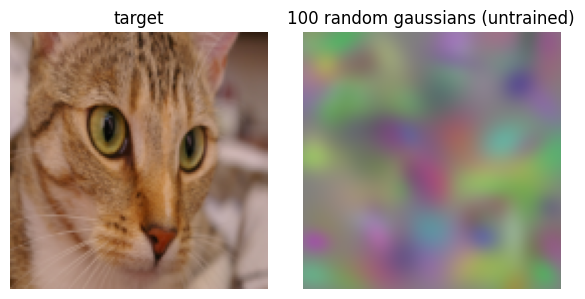

In [4]:
# Cell 7

N_GAUSSIANS = 100
SEED = 0

torch.manual_seed(SEED)
model = GaussianSplat2D(n_gaussians=N_GAUSSIANS, height=H, width=W, seed=SEED)

with torch.no_grad():
    initial_render = model.render().numpy()

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(target_np); axes[0].set_title("target"); axes[0].axis("off")
axes[1].imshow(np.clip(initial_render, 0, 1)); axes[1].set_title(f"{N_GAUSSIANS} random gaussians (untrained)"); axes[1].axis("off")
plt.tight_layout()
plt.show()

<!-- Cell 8 -->
## 4. Training

In [5]:
# Cell 9

N_ITERS = 1000
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

# --- Densification schedule ---
DENSIFY_FROM = 100          # let positions settle a bit before densifying
DENSIFY_UNTIL = 800         # stop densifying near the end so training can converge
DENSIFY_EVERY = 100

loss_history = []
n_gaussians_history = []
snapshots = {}
snapshot_iters = {0, 20, 40, 60, 100, 150, 400, N_ITERS - 1}

t0 = time.time()

for it in range(N_ITERS):
    optimizer.zero_grad()

    rendered = model.render()
    loss = F.l1_loss(rendered, target_t)
    loss.backward()

    model.accumulate_grad_stats()

    optimizer.step()

    loss_history.append(loss.item())
    n_gaussians_history.append(model.N)

    if it % 100 == 0 or it == N_ITERS - 1:
        print(
            f"iter {it:4d} | loss {loss.item():.4f} | "
            f"N {model.N:4d} | elapsed {time.time() - t0:.1f}s"
        )

    if it in snapshot_iters:
        snapshots[it] = rendered.detach().clamp(0, 1).numpy()

    if (
        DENSIFY_FROM <= it < DENSIFY_UNTIL
        and it % DENSIFY_EVERY == 0
    ):
        clone_N, split_N, remove_N = model.densify_and_prune()
        # Parameter tensors were replaced (new identities/shapes), so
        # Adam's per-parameter state can't carry over — start fresh.
        optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

        print(f"\t\t\t\t\t\t DENSIFY | clone {clone_N:4d}, split {split_N:4d}, remove {remove_N:4d} | Resultant N {model.N:4d}")

print(f"training done in {time.time() - t0:.1f}s")

iter    0 | loss 0.1421 | N  100 | elapsed 0.0s
iter  100 | loss 0.0459 | N  100 | elapsed 3.7s
						 DENSIFY | clone    5, split   21, remove   44 | Resultant N   88
iter  200 | loss 0.0397 | N   88 | elapsed 6.8s
						 DENSIFY | clone    3, split   27, remove   14 | Resultant N  105
iter  300 | loss 0.0356 | N  105 | elapsed 11.8s
						 DENSIFY | clone   15, split   35, remove   13 | Resultant N  145
iter  400 | loss 0.0310 | N  145 | elapsed 19.2s
						 DENSIFY | clone   21, split   32, remove   10 | Resultant N  190
iter  500 | loss 0.0284 | N  190 | elapsed 28.4s
						 DENSIFY | clone   17, split   30, remove   10 | Resultant N  229
iter  600 | loss 0.0269 | N  229 | elapsed 39.5s
						 DENSIFY | clone   16, split   23, remove   13 | Resultant N  255
iter  700 | loss 0.0254 | N  255 | elapsed 52.3s
						 DENSIFY | clone   12, split   21, remove   13 | Resultant N  275
iter  800 | loss 0.0235 | N  275 | elapsed 66.3s
iter  900 | loss 0.0222 | N  275 | elapsed 80.5s
iter  999

<!-- Cell 10 -->

## 5. Loss curve

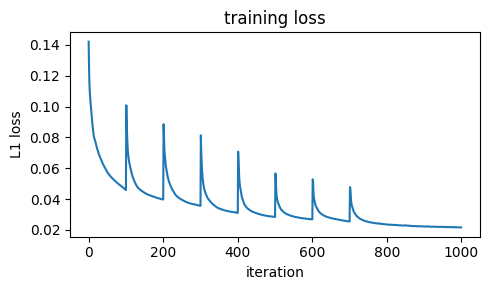

In [6]:
# Cell 11

plt.figure(figsize=(5, 3))
plt.plot(loss_history)
plt.xlabel("iteration")
plt.ylabel("L1 loss")
plt.title("training loss")
plt.tight_layout()
plt.show()

<!-- Cell 12 -->

## 6. Final result

reconstruction
PSNR 29.12 dB, SSIM 0.837


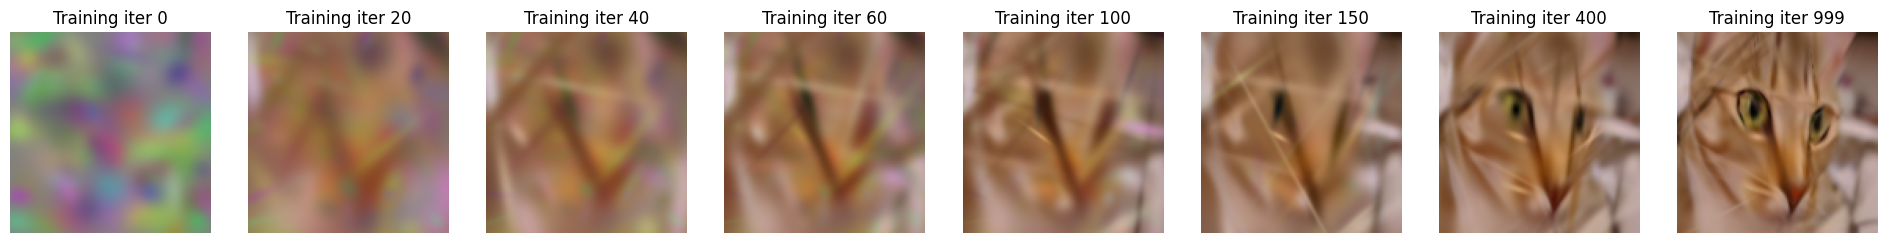

In [7]:
# Cell 13

final_np = snapshots[N_ITERS - 1]
final_render = torch.from_numpy(final_np)

mse = torch.mean((final_render - target_t) ** 2).item()
psnr = 10 * math.log10(1.0 / mse) if mse > 0 else float("inf")
ssim_score = ssim(target_np, final_np, channel_axis=-1, data_range=1.0)
print(f"reconstruction\nPSNR {psnr:.2f} dB, SSIM {ssim_score:.3f}")

iters_sorted = sorted(snapshots.keys())
fig, axes = plt.subplots(1, len(iters_sorted), figsize=(2.4 * len(iters_sorted), 2.4))
for ax, it in zip(axes, iters_sorted):
    ax.imshow(snapshots[it])
    ax.set_title(f"Training iter {it}")
    ax.axis("off")
plt.tight_layout()
plt.show()


<!-- Cell 14 -->
## 7. Visualize the effect of Gaussian draw order

After training, render the model several more times using randomized orders. The Gaussian parameters remain unchanged; only the front-to-back compositing order varies.

This illustrates that alpha compositing is order-dependent. The rendered results with monotonic order (i.e. the setup used for training) is shown on the right for visual comparison.

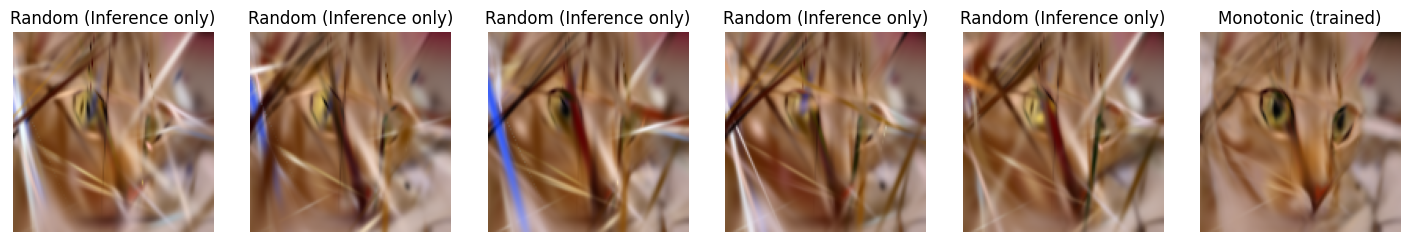

In [8]:
# Cell 15

N_RANDOM = 5

with torch.no_grad():
    renders = [model.render(random_gaussian_order=True).clamp(0, 1).numpy() for _ in range(N_RANDOM)] + [final_np]
    subtitles = ['Random (Inference only)']*N_RANDOM + ['Monotonic (trained)']

fig, axes = plt.subplots(1, N_RANDOM + 1, figsize=(2.4 * (N_RANDOM + 1), 2.4), squeeze=False)

for ax, image, subtitle in zip(axes[0], renders, subtitles):
    ax.imshow(image)
    ax.set_title(subtitle)
    ax.axis("off")

plt.tight_layout()
plt.show()